# 05 - Comparação de Modelos

No notebook anterior a regressão logística ficou como referência a ser
superada. Aqui testo modelos mais fortes, com o mesmo pré-processamento e a
mesma validação cruzada no tempo:

- **Random Forest** e **Gradient Boosting** (conjuntos de árvores);
- **XGBoost** (outro gradient boosting, muito usado na prática);
- **Rede neural (MLP)**, que também faz parte do conteúdo da disciplina.

Todos entram no mesmo dicionário e passam pelo mesmo laço, então a comparação
é justa. No fim escolho um modelo para o ajuste fino.

## 1. Preparação

In [1]:
import sys
sys.path.append("..")
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, StratifiedKFold, cross_validate

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from src.preprocessing import (preparar, separar_treino_teste,
                               VARIAVEIS_NUMERICAS, VARIAVEIS_CATEGORICAS, ALVO)

pd.set_option("display.float_format", lambda x: f"{x:.3f}")

In [2]:
df = preparar()
treino, teste = separar_treino_teste(df)

variaveis = VARIAVEIS_NUMERICAS + VARIAVEIS_CATEGORICAS
X_treino, y_treino = treino[variaveis], treino[ALVO]
X_teste, y_teste = teste[variaveis], teste[ALVO]

preproc = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc", StandardScaler()),
    ]), VARIAVEIS_NUMERICAS),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]), VARIAVEIS_CATEGORICAS),
])

## 2. Os modelos

Um `class_weight="balanced"` onde o modelo aceita, para não ignorar a classe
de cancelamento. Para o XGBoost uso o `scale_pos_weight` equivalente.

In [3]:
peso_pos = (y_treino == 0).sum() / (y_treino == 1).sum()

modelos = {
    "regressão logística": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "árvore de decisão": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "random forest": RandomForestClassifier(n_estimators=200, class_weight="balanced",
                                            random_state=42, n_jobs=4),
    "gradient boosting": HistGradientBoostingClassifier(random_state=42),
    "xgboost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5,
                             subsample=0.9, scale_pos_weight=peso_pos,
                             eval_metric="logloss", random_state=42, n_jobs=4),
    "rede neural (mlp)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300,
                                       random_state=42),
}

## 3. Validação cruzada no tempo

Mesmo esquema do notebook 04: `TimeSeriesSplit`, mesmo `cv` para todos.

In [4]:
cv = TimeSeriesSplit(n_splits=5)
metricas = ["roc_auc", "average_precision", "f1", "recall"]

linhas = []
for nome, modelo in modelos.items():
    pipe = Pipeline([("prep", preproc), ("modelo", modelo)])
    r = cross_validate(pipe, X_treino, y_treino, cv=cv, scoring=metricas)
    linhas.append({
        "modelo": nome,
        "roc_auc": r["test_roc_auc"].mean(),
        "pr_auc": r["test_average_precision"].mean(),
        "f1": r["test_f1"].mean(),
        "recall": r["test_recall"].mean(),
    })

tabela = pd.DataFrame(linhas).set_index("modelo").round(3).sort_values("pr_auc", ascending=False)
tabela

,roc_auc,pr_auc,f1,recall
modelo,,,,
xgboost,0.897,0.851,0.706,0.623
random forest,0.887,0.843,0.626,0.484
gradient boosting,0.886,0.837,0.652,0.532
regressão logística,0.872,0.819,0.689,0.622
rede neural (mlp),0.840,0.781,0.623,0.534
árvore de decisão,0.725,0.572,0.626,0.549


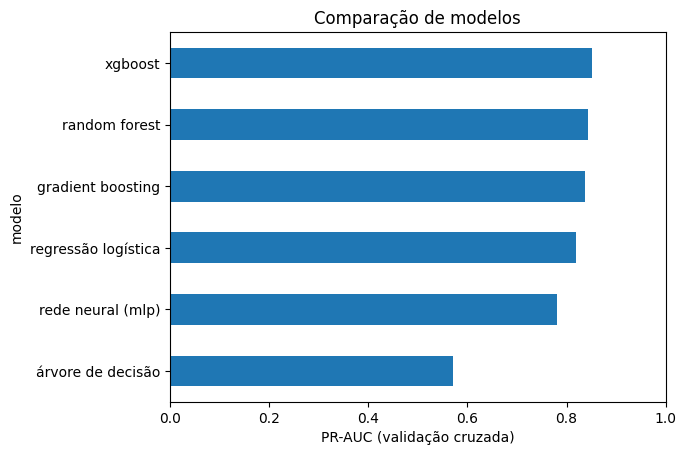

In [5]:
tabela["pr_auc"].sort_values().plot(kind="barh")
plt.xlim(0, 1)
plt.xlabel("PR-AUC (validação cruzada)")
plt.title("Comparação de modelos")
plt.show()

In [6]:
# guarda a figura para o README (sobe uma pasta, entra em reports/figures)
plt.figure()
tabela["pr_auc"].sort_values().plot(kind="barh")
plt.xlim(0, 1)
plt.xlabel("PR-AUC (validação cruzada)")
plt.title("Comparação de modelos")
plt.tight_layout()
plt.savefig("../reports/figures/comparacao_modelos.png")
plt.close()

Os gradient boostings (gradient boosting e XGBoost) e o random forest ficam à
frente da regressão logística em ROC-AUC e PR-AUC. A rede neural fica no meio.
A árvore única sem poda é a pior do grupo em probabilidade.

O maior ganho aparece na PR-AUC, que é a métrica que mais interessa aqui
porque olha o desempenho na classe de cancelamento.

## 4. Corte temporal x corte aleatório

O modelo de referência de várias aulas usa K-Fold aleatório. Aqui mostro por
que o corte aleatório não serve para este problema: com dados fora de ordem
no tempo, o modelo acaba treinando com o "futuro" e o desempenho parece
melhor do que é.

In [7]:
cv_aleatorio = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

comparacao = []
for nome in ["regressão logística", "random forest", "xgboost"]:
    pipe = Pipeline([("prep", preproc), ("modelo", modelos[nome])])
    r_tempo = cross_validate(pipe, X_treino, y_treino, cv=cv, scoring="average_precision")
    r_alea = cross_validate(pipe, X_treino, y_treino, cv=cv_aleatorio, scoring="average_precision")
    comparacao.append({"modelo": nome,
                       "pr_auc corte no tempo": r_tempo["test_score"].mean(),
                       "pr_auc corte aleatório": r_alea["test_score"].mean()})

pd.DataFrame(comparacao).set_index("modelo").round(3)

,pr_auc corte no tempo,pr_auc corte aleatório
modelo,,
regressão logística,0.819,0.874
random forest,0.843,0.949
xgboost,0.851,0.929


O corte aleatório dá uma PR-AUC mais alta para todos os modelos. Não é o
modelo que melhorou: é a avaliação que ficou otimista, porque misturou
reservas de todos os períodos. Como o objetivo é prever cancelamentos
futuros, a avaliação correta é a do corte no tempo.

## 5. Escolha para o próximo notebook

In [8]:
melhor = tabela["pr_auc"].idxmax()
print("melhor modelo por PR-AUC:", melhor)
tabela

melhor modelo por PR-AUC: xgboost


,roc_auc,pr_auc,f1,recall
modelo,,,,
xgboost,0.897,0.851,0.706,0.623
random forest,0.887,0.843,0.626,0.484
gradient boosting,0.886,0.837,0.652,0.532
regressão logística,0.872,0.819,0.689,0.622
rede neural (mlp),0.840,0.781,0.623,0.534
árvore de decisão,0.725,0.572,0.626,0.549


- o **XGBoost** teve a melhor PR-AUC e um bom equilíbrio de recall. É o modelo
  que levo para o notebook 06;
- o random forest e o gradient boosting ficaram perto e servem de conferência;
- a rede neural não trouxe vantagem que justifique a complexidade;
- a regressão logística continua útil como referência simples.

No notebook 06 faço o ajuste de hiperparâmetros do XGBoost, comparo a
calibração das probabilidades e escolho o limiar de decisão.